# 5G NR Digital Twin — Multi-BS Multi-UE Wireless Network

## Megamas, Manado — Indonesia


### CELL 1 — Libraries


In [1]:
# ================================================================
# CELL 1 — Libraries
# ================================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf, sionna
tf.get_logger().setLevel('ERROR')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
print("TensorFlow:", tf.__version__)

import sionna.phy, sionna.sys, sionna.rt
print("Sionna imported.")

import subprocess
subprocess.run(["pip", "install", "sumolib", "--break-system-packages", "-q"])

import sys
os.environ["SUMO_HOME"] = "/Library/Frameworks/EclipseSUMO.framework/Versions/1.26.0/EclipseSUMO/share/sumo"
tools = os.path.join(os.environ["SUMO_HOME"], "tools")
if tools not in sys.path:
    sys.path.append(tools)

import traci
print("Traci imported.")

import matplotlib.pyplot as plt
import numpy as np

from sionna.rt import (load_scene, Transmitter, Receiver, PlanarArray,
                       RadioMapSolver, ITURadioMaterial, SceneObject,
                       PathSolver, subcarrier_frequencies, Camera)
from sionna.phy import config
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import (ResourceGrid, RZFPrecodedChannel,
                              LMMSEPostEqualizationSINR)
from sionna.phy.constants import BOLTZMANN_CONSTANT
from sionna.phy.nr.utils import decode_mcs_index
from sionna.phy.utils import log2, dbm_to_watt, lin_to_db
from sionna.sys import (PHYAbstraction, OuterLoopLinkAdaptation,
                        PFSchedulerSUMIMO, downlink_fair_power_control)
from sionna.sys.utils import spread_across_subcarriers

config.precision = 'single'
config.seed = 48
no_preview = True

TensorFlow: 2.19.1
Sionna imported.
Traci imported.


### CELL 2 — Scene + Cars (cars are scatterers)


In [2]:
# ================================================================
# CELL 2 — Scene + Cars (cars are scatterers)
# ================================================================
scene_path = "manado_scene/megamas2.xml"
scene = load_scene(scene_path)

num_cars = 3
car_material = ITURadioMaterial("car-material", "metal",
                                thickness=0.5, color=(0.8, 0.1, 0.1))
cars = [SceneObject(fname=sionna.rt.scene.low_poly_car,
                    name=f"car-{i}",
                    radio_material=car_material)
        for i in range(num_cars)]
scene.edit(add=cars)

print(f"Scene loaded: {scene_path}")
print(f"Total objects: {len(scene.objects)}")

Scene loaded: manado_scene/megamas2.xml
Total objects: 6


### CELL 3 — Simulation Parameters + BS placement + SM/RG

_Patches applied: #3_


In [3]:
# ================================================================
# CELL 3 — Simulation Parameters + BS placement + SM/RG
# [PATCH #3 applied: Doppler / coherence-time sanity check]
# ================================================================
num_slots         = 200
slot_duration     = 0.1
total_sim_time    = num_slots * slot_duration
nr_slot_duration  = 0.0005

carrier_frequency  = 3.5e9
num_subcarriers    = 612
subcarrier_spacing = 30e3
num_ofdm_symbols   = 14
bandwidth_hz       = num_subcarriers * subcarrier_spacing

bs_pos_1     = [-8.2521, 315.64, 35.0]
bs_pos_2     = [270.0, -180.2, 35.0]
bs_pos_3     = [-199, -400.1, 35.0]
bs_look_at_1 = [165.74, -226.17, 1.5]
bs_look_at_2 = [-300.0, 60.0, 1.5]
bs_look_at_3 = [503.5, 181.3, 1.5]

num_bs = 3
num_ut = num_cars

temperature     = 303.15
bler_target     = 0.1
mcs_table_index = 1
bs_power_dbm    = 44
bs_power_watt   = dbm_to_watt(bs_power_dbm)

scene.bandwidth   = bandwidth_hz
scene.temperature = temperature

num_bs_ant = 16
num_ut_ant = 4

scene.tx_array = PlanarArray(num_rows=2, num_cols=4,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="tr38901", polarization="cross")
scene.rx_array = PlanarArray(num_rows=1, num_cols=2,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="dipole", polarization="cross")

scene.add(Transmitter(name="bs0", position=bs_pos_1, power_dbm=bs_power_dbm))
scene.add(Transmitter(name="bs1", position=bs_pos_2, power_dbm=bs_power_dbm))
scene.add(Transmitter(name="bs2", position=bs_pos_3, power_dbm=bs_power_dbm))

scene.transmitters["bs0"].look_at(bs_look_at_1)
scene.transmitters["bs1"].look_at(bs_look_at_2)
scene.transmitters["bs2"].look_at(bs_look_at_3)

num_streams_per_ut = 4
no = BOLTZMANN_CONSTANT * temperature * subcarrier_spacing


def make_sm_rg(n_ut):
    rx_tx = np.ones([n_ut, 1])
    sm = StreamManagement(rx_tx, num_streams_per_tx=n_ut * num_ut_ant)
    rg = ResourceGrid(
        num_ofdm_symbols=num_ofdm_symbols,
        fft_size=num_subcarriers,
        subcarrier_spacing=subcarrier_spacing,
        num_tx=1,
        num_streams_per_tx=n_ut * num_ut_ant)
    return sm, rg


sm_cfg, rg_cfg = {}, {}
for n in [1, 2, 3]:
    sm_cfg[n], rg_cfg[n] = make_sm_rg(n)

frequencies = subcarrier_frequencies(
    num_subcarriers=num_subcarriers,
    subcarrier_spacing=subcarrier_spacing)

print(f"Sim : {num_slots} slots × {slot_duration*1000:.0f} ms = {total_sim_time:.1f} s")
print(f"BW  : {bandwidth_hz/1e6:.2f} MHz, fc = {carrier_frequency/1e9:.1f} GHz")
print(f"BS  : {num_bs}, antennas/BS = {num_bs_ant}")
print(f"UE  : {num_ut}, antennas/UE = {num_ut_ant}")
print("SM/RG configs ready for n_ut in {1, 2, 3}")

# --- [PATCH #3] Doppler / coherence-time sanity check ---
print("\n" + "=" * 60)
print(" CHANNEL COHERENCE SANITY CHECK [Patch #3]")
print("=" * 60)
v_assumed_kmh = 30.0
v_assumed_ms  = v_assumed_kmh / 3.6
f_d_max       = v_assumed_ms * carrier_frequency / 3e8
coherence_time_s  = 0.423 / f_d_max
coherence_time_ms = coherence_time_s * 1000
outer_step_ms     = slot_duration * 1000
ici_ratio         = f_d_max / subcarrier_spacing

print(f"Assumed UE speed         : {v_assumed_kmh:.1f} km/h ({v_assumed_ms:.2f} m/s)")
print(f"Max Doppler shift f_d    : {f_d_max:.1f} Hz")
print(f"Coherence time T_c       : {coherence_time_ms:.2f} ms (Clarke)")
print(f"Outer step duration      : {outer_step_ms:.1f} ms")
print(f"Outer step / T_c ratio   : {outer_step_ms / coherence_time_ms:.1f}x")
print(f"ICI ratio f_d / dF       : {ici_ratio:.4f} "
      f"({'negligible' if ici_ratio < 0.01 else 'non-negligible'})")
if outer_step_ms > 5 * coherence_time_ms:
    print(f"  NOTE: outer step >> T_c. Intra-step small-scale fading")
    print(f"  is NOT captured by quasi-static assumption.")
    print(f"  Sustained throughput may be optimistic.")
print("=" * 60)

Sim : 200 slots × 100 ms = 20.0 s
BW  : 18.36 MHz, fc = 3.5 GHz
BS  : 3, antennas/BS = 16
UE  : 3, antennas/UE = 4
SM/RG configs ready for n_ut in {1, 2, 3}

 CHANNEL COHERENCE SANITY CHECK [Patch #3]
Assumed UE speed         : 30.0 km/h (8.33 m/s)
Max Doppler shift f_d    : 97.2 Hz
Coherence time T_c       : 4.35 ms (Clarke)
Outer step duration      : 100.0 ms
Outer step / T_c ratio   : 23.0x
ICI ratio f_d / dF       : 0.0032 (negligible)
  NOTE: outer step >> T_c. Intra-step small-scale fading
  is NOT captured by quasi-static assumption.
  Sustained throughput may be optimistic.


### CELL 4 — Parse SUMO net + routes -> per-vehicle waypoints


In [4]:
# ================================================================
# CELL 4 — Parse SUMO net + routes -> per-vehicle waypoints
# ================================================================
import sumolib
import xml.etree.ElementTree as ET

SUMO_NET    = "sumo_projects/tutorial1/net.net.xml"
SUMO_ROUTES = "sumo_projects/tutorial1/random_routes.rou.xml"

X_SHIFT = 547.205
Y_SHIFT = 667.03


def sumo_to_sionna(x_sumo, y_sumo, z=1.5):
    return [x_sumo - X_SHIFT, y_sumo - Y_SHIFT, z]


net = sumolib.net.readNet(SUMO_NET, withInternal=False)
print(f"SUMO net loaded: {len(net.getEdges())} edges")

tree = ET.parse(SUMO_ROUTES)
root = tree.getroot()
route_defs = {r.get("id"): r.get("edges", "").split()
              for r in root.findall("route")}

vehicle_edges, vehicle_depart = {}, {}
for veh in root.findall("vehicle"):
    vid = veh.get("id")
    depart = float(veh.get("depart", 0))
    re_elem = veh.find("route")
    edges = (re_elem.get("edges", "").split() if re_elem is not None
             else route_defs.get(veh.get("route"), []))
    vehicle_edges[vid] = edges
    vehicle_depart[vid] = depart


def edges_to_waypoints(edge_ids, net, z=1.5, step=2):
    pts = []
    for eid in edge_ids:
        try:
            shape = net.getEdge(eid).getShape()
        except Exception:
            continue
        for i, (x, y) in enumerate(shape):
            if i % step == 0:
                pts.append(sumo_to_sionna(x, y, z))
    if len(pts) < 2:
        return pts
    out = [pts[0]]
    for p in pts[1:]:
        if np.hypot(p[0] - out[-1][0], p[1] - out[-1][1]) > 1.0:
            out.append(p)
    return out


sorted_vehs = sorted(vehicle_edges.keys(),
                     key=lambda v: vehicle_depart.get(v, 0))[:num_cars]

routes = []
for vid in sorted_vehs:
    wpts = edges_to_waypoints(vehicle_edges[vid], net)
    if len(wpts) < 2:
        print(f"  WARN: {vid} only has {len(wpts)} waypoint(s) - skipped")
        continue
    routes.append(wpts)

if not routes:
    raise RuntimeError("No valid routes from SUMO.")
while len(routes) < num_cars:
    routes.append(routes[-1])
    print("  WARN: SUMO vehicles < num_cars, padding with last route")


def total_distance(wpts):
    return sum(np.hypot(wpts[i+1][0]-wpts[i][0], wpts[i+1][1]-wpts[i][1])
               for i in range(len(wpts)-1))


def position_on_route(wpts, progress):
    if len(wpts) == 1:
        return wpts[0]
    target = progress * total_distance(wpts)
    cum = 0.0
    for i in range(len(wpts)-1):
        dx = wpts[i+1][0] - wpts[i][0]
        dy = wpts[i+1][1] - wpts[i][1]
        seg = np.hypot(dx, dy)
        if cum + seg >= target:
            t = (target - cum) / max(seg, 1e-9)
            return [wpts[i][0] + t*dx, wpts[i][1] + t*dy, wpts[i][2]]
        cum += seg
    return wpts[-1]


print("\nRoute summary:")
for i, r in enumerate(routes):
    d = total_distance(r)
    print(f"  Car {i}: {len(r)} waypoints, planned route length = {d:.0f} m")

for i in range(num_cars):
    p = [float(v) for v in position_on_route(routes[i], 0.0)]
    scene.add(Receiver(name=f"rx-car-{i}", position=p))

SUMO net loaded: 496 edges

Route summary:
  Car 0: 50 waypoints, planned route length = 1333 m
  Car 1: 17 waypoints, planned route length = 705 m
  Car 2: 20 waypoints, planned route length = 915 m


### CELL 5 — Ray-Path Visualization (mid-route snapshot)


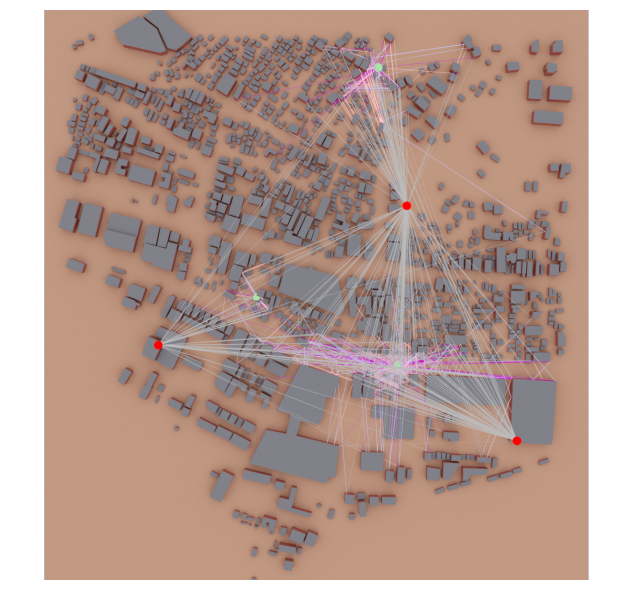

In [5]:
# ================================================================
# CELL 5 — Ray-Path Visualization (mid-route snapshot)
# ================================================================
for i in range(num_cars):
    p = [float(v) for v in position_on_route(routes[i], 0.5)]
    scene.receivers[f"rx-car-{i}"].position = p

p_solver = PathSolver()
paths = p_solver(
    scene=scene, max_depth=5,
    los=True, specular_reflection=True, diffuse_reflection=False,
    refraction=True, diffraction=True,
    synthetic_array=False, seed=42)

scene_center_x, scene_center_y = 92.0, 5.0
cam_altitude = 1500.0

if no_preview:
    cam = Camera(
        position=[scene_center_x, scene_center_y, cam_altitude],
        look_at=[scene_center_x, scene_center_y, 0.0])
    scene.render(camera=cam, paths=paths,
                 resolution=[1600, 1500])
else:
    scene.preview(paths=paths)

In [ ]:
# ================================================================
# CELL 5 — Ray-Path Visualization (mid-route snapshot)
# Save ray tracing capture as PNG
# ================================================================
import os
import matplotlib.pyplot as plt
from sionna.rt import PathSolver, Camera

# ── 1. Move each receiver to the middle of its route ─────────────
for i in range(num_cars):
    p = [float(v) for v in position_on_route(routes[i], 0.5)]
    scene.receivers[f"rx-car-{i}"].position = p

# ── 2. Compute ray paths ────────────────────────────────────────
p_solver = PathSolver()

paths = p_solver(
    scene=scene,
    max_depth=5,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=True,
    diffraction=True,
    synthetic_array=False,
    seed=42
)

# ── 3. Camera setting ───────────────────────────────────────────
scene_center_x, scene_center_y = 92.0, 5.0
cam_altitude = 1500.0

# ── 4. Output path ──────────────────────────────────────────────
os.makedirs("figures", exist_ok=True)
output_path = "figures/ray_tracing_mid_route.png"

# ── 5. Render and save as PNG ───────────────────────────────────
if no_preview:
    cam = Camera(
        position=[scene_center_x, scene_center_y, cam_altitude],
        look_at=[scene_center_x, scene_center_y, 0.0]
    )

    fig = scene.render(
        camera=cam,
        paths=paths,
        resolution=[1600, 1500]
    )

    # Save rendered figure as PNG
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)

    print(f"Ray tracing image saved as: {output_path}")

    plt.show()
    plt.close(fig)

else:
    scene.preview(paths=paths)

In [6]:
# ================================================================
# CELL 5B — Ray-Tracing Animation over 20 seconds
# Output: GIF animation
# ================================================================
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from sionna.rt import PathSolver, Camera

# ── 1. Animation settings ───────────────────────────────────────
sim_duration = 20.0          # seconds
num_frames = 21              # 21 frames: t = 0, 1, 2, ..., 20
fps = 4                      # GIF playback speed

frame_dir = "ray_frames"
os.makedirs(frame_dir, exist_ok=True)

gif_path = "ray_tracing_20s_animation.gif"

# ── 2. Camera setting ───────────────────────────────────────────
scene_center_x, scene_center_y = 92.0, 5.0
cam_altitude = 1500.0

cam = Camera(
    position=[scene_center_x, scene_center_y, cam_altitude],
    look_at=[scene_center_x, scene_center_y, 0.0]
)

# ── 3. Path solver ──────────────────────────────────────────────
p_solver = PathSolver()

# ── 4. Generate frames ──────────────────────────────────────────
frame_files = []

for frame_idx in range(num_frames):
    # Simulation time
    t = frame_idx / (num_frames - 1) * sim_duration

    # Route fraction: 0 at t=0, 1 at t=20s
    route_frac = t / sim_duration

    print(f"Rendering frame {frame_idx + 1}/{num_frames} at t = {t:.1f}s")

    # Update receiver/car positions
    for i in range(num_cars):
        p = [float(v) for v in position_on_route(routes[i], route_frac)]
        scene.receivers[f"rx-car-{i}"].position = p

    # Recompute ray paths for current car positions
    paths = p_solver(
        scene=scene,
        max_depth=5,
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True,
        diffraction=True,
        synthetic_array=False,
        seed=42
    )

    # Render current snapshot
    fig = scene.render(
        camera=cam,
        paths=paths,
        resolution=[1600, 1500]
    )

    # Save frame
    frame_path = os.path.join(frame_dir, f"ray_frame_{frame_idx:03d}.png")
    fig.savefig(frame_path, dpi=180, bbox_inches="tight", pad_inches=0)

    plt.close(fig)

    frame_files.append(frame_path)

# ── 5. Combine frames into GIF ──────────────────────────────────
frames = [imageio.imread(f) for f in frame_files]
imageio.mimsave(gif_path, frames, fps=fps)

print(f"\nRay-tracing animation saved as: {os.path.abspath(gif_path)}")

Rendering frame 1/21 at t = 0.0s
Rendering frame 2/21 at t = 1.0s
Rendering frame 3/21 at t = 2.0s
Rendering frame 4/21 at t = 3.0s
Rendering frame 5/21 at t = 4.0s
Rendering frame 6/21 at t = 5.0s
Rendering frame 7/21 at t = 6.0s
Rendering frame 8/21 at t = 7.0s
Rendering frame 9/21 at t = 8.0s
Rendering frame 10/21 at t = 9.0s
Rendering frame 11/21 at t = 10.0s
Rendering frame 12/21 at t = 11.0s
Rendering frame 13/21 at t = 12.0s
Rendering frame 14/21 at t = 13.0s
Rendering frame 15/21 at t = 14.0s
Rendering frame 16/21 at t = 15.0s
Rendering frame 17/21 at t = 16.0s
Rendering frame 18/21 at t = 17.0s
Rendering frame 19/21 at t = 18.0s
Rendering frame 20/21 at t = 19.0s
Rendering frame 21/21 at t = 20.0s

Ray-tracing animation saved as: /Users/950284/ray_tracing_20s_animation.gif


### CELL 6 — Compute Radio Map (one-shot)


In [7]:
# ================================================================
# CELL 6 — Compute Radio Map (one-shot)
# ================================================================
inactive_pos = [-9999.0, -9999.0, 1.5]
for rx_name in scene.receivers.keys():
    scene.receivers[rx_name].position = inactive_pos

rm_solver = RadioMapSolver()
rm_center = [92, 5, 1.5]
rm_size   = [1200, 1125]
cell_size_m = 2

rm = rm_solver(scene,
               center=rm_center,
               orientation=[0., 0., 0.],
               size=rm_size,
               cell_size=(cell_size_m, cell_size_m),
               max_depth=5,
               refraction=True,
               samples_per_tx=10_000_000)

extent = [rm_center[0] - rm_size[0]/2, rm_center[0] + rm_size[0]/2,
          rm_center[1] - rm_size[1]/2, rm_center[1] + rm_size[1]/2]

print(f"Radio map computed:")
print(f"  X range : {extent[0]:.0f} to {extent[1]:.0f} m")
print(f"  Y range : {extent[2]:.0f} to {extent[3]:.0f} m")
print(f"  cell    : {cell_size_m} m x {cell_size_m} m")

Radio map computed:
  X range : -508 to 692 m
  Y range : -558 to 568 m
  cell    : 2 m x 2 m


### CELL 7 — Path Gain Heatmap (best server)


In [ ]:
# ================================================================
# CELL 7 — Path Gain Heatmap (best server)
# ================================================================
pg_all_tx = rm.path_gain.numpy()
pg_best   = np.max(pg_all_tx, axis=0)
pg_db     = 10.0 * np.log10(pg_best + 1e-30)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(pg_db, extent=extent, origin='lower',
               cmap='inferno', aspect='equal')
plt.colorbar(im, ax=ax, label='Path gain [dB]')

for bpos, bname in [(bs_pos_1, 'BS0'), (bs_pos_2, 'BS1'), (bs_pos_3, 'BS2')]:
    ax.scatter(bpos[0], bpos[1], marker='^', s=200,
               color='red', edgecolors='white', linewidths=2, zorder=10)
    ax.annotate(bname, (bpos[0], bpos[1]),
                textcoords='offset points', xytext=(8, 8),
                color='white', fontweight='bold', fontsize=10)

ax.set_xlabel('Cell index (X-axis)')
ax.set_ylabel('Cell index (Y-axis)')
ax.set_title('Best Path Gain')
ax.grid(True, alpha=0.2, color='white')
plt.tight_layout()
plt.savefig("path_gain_map.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print(f"Path gain (best server): {pg_db.min():.1f} dB to {pg_db.max():.1f} dB")

### CELL 8 — RSS Heatmap (best server)


In [ ]:
# ================================================================
# CELL 8 — RSS Heatmap (best server)
# ================================================================
rss_per_tx_dbm = 10.0 * np.log10(pg_all_tx + 1e-30) + bs_power_dbm
rss_best_dbm   = np.max(rss_per_tx_dbm, axis=0)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(rss_best_dbm, extent=extent, origin='lower',
               cmap='viridis', aspect='equal',
               vmin=np.percentile(rss_best_dbm, 1),
               vmax=np.percentile(rss_best_dbm, 99))
plt.colorbar(im, ax=ax, label='Received signal strength (RSS) [dBm]')

for bpos, bname in [(bs_pos_1, 'BS0'), (bs_pos_2, 'BS1'), (bs_pos_3, 'BS2')]:
    ax.scatter(bpos[0], bpos[1], marker='^', s=200,
               color='red', edgecolors='white', linewidths=2, zorder=10)
    ax.annotate(bname, (bpos[0], bpos[1]),
                textcoords='offset points', xytext=(8, 8),
                color='white', fontweight='bold', fontsize=10)

ax.set_xlabel('Cell index (X-axis)')
ax.set_ylabel('Cell index (Y-axis)')
ax.set_title('Best RSS')
ax.grid(True, alpha=0.2, color='white')
plt.tight_layout()
plt.savefig("rss_map.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print(f"RSS (best server): {rss_best_dbm.min():.1f} dBm to {rss_best_dbm.max():.1f} dBm")

### CELL 9 — SINR Heatmap (best server)


In [ ]:
# ================================================================
# CELL 9 — SNR Heatmap (best server)
# ================================================================
# SNR is computed from the radio-map path gain, transmit power,
# and thermal noise floor. Unlike SINR, this does not include
# inter-cell interference from other base stations.

pg_all_tx_lin = rm.path_gain.numpy()  # [num_tx, cells_y, cells_x]

# Received signal power per transmitter: RSS[dBm] = path_gain[dB] + Tx_power[dBm]
rss_all_tx_dbm = 10.0 * np.log10(pg_all_tx_lin + 1e-30) + bs_power_dbm
rss_best_dbm   = np.max(rss_all_tx_dbm, axis=0)

# Thermal noise over the configured system bandwidth
noise_power_watt = BOLTZMANN_CONSTANT * temperature * bandwidth_hz
noise_power_dbm  = 10.0 * np.log10(noise_power_watt) + 30.0

# Best-server SNR in dB
snr_best_db = rss_best_dbm - noise_power_dbm

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(snr_best_db, extent=extent, origin='lower',
               cmap='RdYlGn', aspect='equal', vmin=-10, vmax=40)
plt.colorbar(im, ax=ax,
             label='Signal-to-noise ratio (SNR) [dB]')

for bpos, bname in [(bs_pos_1, 'BS0'), (bs_pos_2, 'BS1'), (bs_pos_3, 'BS2')]:
    ax.scatter(bpos[0], bpos[1], marker='^', s=200,
               color='red', edgecolors='white', linewidths=2, zorder=10)
    ax.annotate(bname, (bpos[0], bpos[1]),
                textcoords='offset points', xytext=(8, 8),
                color='black', fontweight='bold', fontsize=10)

ax.set_xlabel('Cell index (X-axis)')
ax.set_ylabel('Cell index (Y-axis)')
ax.set_title('Best SNR')
ax.grid(True, alpha=0.2, color='black')
plt.tight_layout()
plt.savefig("snr_map.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')

print(f"Noise floor: {noise_power_dbm:.1f} dBm over {bandwidth_hz/1e6:.2f} MHz")
print(f"SNR (best server): {np.nanmin(snr_best_db):.1f} dB to {np.nanmax(snr_best_db):.1f} dB")
print(f"Median SNR: {np.nanmedian(snr_best_db):.1f} dB")


### CELL 10 — Per-Slot CFR Generation via SUMO + Ray Tracing


In [ ]:
# ================================================================
# CELL 10 — Per-Slot CFR Generation via SUMO + Ray Tracing
# ================================================================
veh_to_rx_slot: dict = {}
next_free_slot = 0


def assign_slot(veh_id):
    global next_free_slot
    if veh_id in veh_to_rx_slot:
        return veh_to_rx_slot[veh_id]
    if next_free_slot < num_ut:
        veh_to_rx_slot[veh_id] = next_free_slot
        next_free_slot += 1
        print(f"  [slot assign] {veh_id} -> rx-car-{veh_to_rx_slot[veh_id]}")
        return veh_to_rx_slot[veh_id]
    return None


h_freq = np.zeros(
    [num_slots, num_ut, num_ut_ant, num_bs, num_bs_ant,
     num_ofdm_symbols, num_subcarriers], dtype=np.complex64)
active_mask = np.zeros([num_slots, num_ut], dtype=bool)
sanity_log = []

p_solver = PathSolver()
for rx_name in scene.receivers.keys():
    scene.receivers[rx_name].position = inactive_pos

SUMO_BIN = "/Library/Frameworks/EclipseSUMO.framework/Versions/1.26.0/EclipseSUMO/bin/sumo"
sumo_cmd = [SUMO_BIN, "-c", "sumo_projects/tutorial1/random_sim.sumocfg",
            "--no-warnings", "--no-step-log"]
traci.start(sumo_cmd)

for ii in range(num_slots):
    traci.simulationStep()
    sim_t = traci.simulation.getTime()
    active_ids = set(traci.vehicle.getIDList())
    log = {"slot": ii, "sim_time": float(sim_t),
           "active_ids": list(active_ids)}

    for rx_name in scene.receivers.keys():
        scene.receivers[rx_name].position = inactive_pos

    active_uts = []
    for vid in active_ids:
        sidx = assign_slot(vid)
        if sidx is None:
            continue
        x_s, y_s = traci.vehicle.getPosition(vid)
        pos = [float(v) for v in sumo_to_sionna(x_s, y_s, 1.5)]
        scene.receivers[f"rx-car-{sidx}"].position = pos
        log[f"rx-car-{sidx}"] = pos
        active_uts.append(sidx)
        active_mask[ii, sidx] = True

    if not active_uts:
        log["num_paths"] = 0
        sanity_log.append(log)
        if ii % 20 == 0 or ii == num_slots - 1:
            print(f"Slot {ii+1}/{num_slots}, t={sim_t:.1f}s, active=[] -> skip RT")
        continue

    paths_ii = p_solver(
        scene=scene, max_depth=5,
        los=True, specular_reflection=True, diffuse_reflection=False,
        refraction=True, diffraction=True,
        synthetic_array=False, seed=42)

    h_f_out = paths_ii.cfr(frequencies=frequencies)
    h_f = h_f_out[0] if isinstance(h_f_out, tuple) else h_f_out
    h_f_np = h_f.numpy()

    expected = (num_ut, num_ut_ant, num_bs, num_bs_ant,
                num_ofdm_symbols, num_subcarriers)
    if h_f_np.shape != expected:
        h_f_np = np.broadcast_to(h_f_np, expected).copy()

    for ut in range(num_ut):
        if not active_mask[ii, ut]:
            h_f_np[ut] = 0.0

    h_freq[ii] = h_f_np.astype(np.complex64)

    a, _ = paths_ii.cir(normalize_delays=True, out_type="numpy")
    log["num_paths"] = int(a.shape[-2])
    sanity_log.append(log)

    if ii % 20 == 0 or ii == num_slots - 1:
        print(f"Slot {ii+1}/{num_slots}, t={sim_t:.1f}s, active={sorted(active_uts)}")

traci.close()
h_freq = tf.constant(h_freq)
print(f"\nh_freq shape: {h_freq.shape}")
print(f"Vehicle -> RX-slot: {veh_to_rx_slot}")
print(f"Active slots per UT: {active_mask.sum(axis=0)}")

### CELL 11 — Instantiate PHYAbstraction / OLLA / Scheduler


In [ ]:
# ================================================================
# CELL 11 — Instantiate PHYAbstraction / OLLA / Scheduler
# ================================================================
phy_abs = {bs: {n: PHYAbstraction() for n in [1, 2, 3]}
           for bs in range(num_bs)}

olla = {bs: {n: OuterLoopLinkAdaptation(
                phy_abs[bs][n], num_ut=n,
                bler_target=bler_target, batch_size=[1])
             for n in [1, 2, 3]}
        for bs in range(num_bs)}

scheduler = {bs: {n: PFSchedulerSUMIMO(
                    n, num_subcarriers, num_ofdm_symbols,
                    batch_size=[1],
                    num_streams_per_ut=num_streams_per_ut)
                  for n in [1, 2, 3]}
             for bs in range(num_bs)}

print("PHY / OLLA / Scheduler instantiated.")

### CELL 12 — Per-slot per-BS step function

_Patch #2 DISABLED: reverted to thermal-noise-only LMMSE. The first-order ICI approximation over-estimated interference power (50-80 dB above thermal), causing system-level SINR collapse. Proper multicell LMMSE with spatial covariance R_ii left as future work._


In [ ]:
# ================================================================
# CELL 12 — Per-slot per-BS step function
# [PATCH #2 DISABLED — reverted to thermal-noise-only LMMSE]
#
# Note: The first-order ICI approximation initially added in Patch #2
# was found to over-estimate interference power (raw |h|^2 × Tx_power
# without proper spatial whitening produced ICI values 50-80 dB above
# thermal noise, causing system-level SINR collapse). The proper
# multicell LMMSE with spatial covariance R_ii is left as future work.
# Inter-cell interference remains modeled only in the propagation-
# layer radio map (Cell 9), consistent with paper Limitations.
# ================================================================
def estimate_achievable_rate(channel_gain, no_):
    rate = log2(tf.cast(1, tf.float32) + channel_gain / no_)
    rate = tf.reduce_mean(rate, axis=[-3, -5])
    rate = tf.transpose(rate, [1, 2, 3, 0])
    return rate


def step_bs(h, harq_feedback, sinr_eff_feedback, num_decoded_bits,
            bs_id, n_ut):
    """
    Per-slot per-BS system-level processing.
    Uses thermal noise only (Patch #2 ICI approximation disabled).
    """
    sm   = sm_cfg[n_ut]
    rg   = rg_cfg[n_ut]
    _phy = phy_abs[bs_id][n_ut]
    _ola = olla[bs_id][n_ut]
    _sch = scheduler[bs_id][n_ut]

    channel_gain = tf.cast(tf.abs(h)**2, tf.float32)
    channel_gain = tf.maximum(channel_gain, 1e-12)
    rate_est = estimate_achievable_rate(channel_gain, no)

    is_scheduled = _sch(num_decoded_bits, rate_est)
    num_allocated_re = tf.reduce_sum(
        tf.cast(is_scheduled, tf.int32), axis=[-4, -3, -1])

    pathloss = tf.reduce_mean(1.0 / channel_gain, axis=[1, 3, 4, 5])
    pathloss = tf.transpose(pathloss, [1, 0])
    tx_power_per_ut, _ = downlink_fair_power_control(
        pathloss, no, num_allocated_re,
        bs_max_power_dbm=bs_power_dbm,
        guaranteed_power_ratio=0.5,
        fairness=0)
    tx_power = spread_across_subcarriers(
        tf.expand_dims(tx_power_per_ut, axis=-2),
        is_scheduled, num_tx=1)

    h_eff = RZFPrecodedChannel(resource_grid=rg, stream_management=sm)(
        h[tf.newaxis, ...], tx_power=tx_power, alpha=no)
    sinr = LMMSEPostEqualizationSINR(resource_grid=rg, stream_management=sm)(
        h_eff, no=no, interference_whitening=True)

    mcs_index = _ola(
        num_allocated_re=num_allocated_re,
        sinr_eff=sinr_eff_feedback,
        mcs_table_index=mcs_table_index,
        mcs_category=1,
        harq_feedback=harq_feedback)

    num_decoded_bits, harq_feedback, sinr_eff_true, *_ = _phy(
        mcs_index, sinr=sinr,
        mcs_table_index=mcs_table_index, mcs_category=1)

    sinr_eff_db = lin_to_db(sinr_eff_true)
    sinr_eff_feedback = tf.where(num_allocated_re > 0,
                                  sinr_eff_true, 0.0)

    return (harq_feedback, sinr_eff_feedback, num_decoded_bits,
            sinr_eff_db, mcs_index, num_allocated_re)


### CELL 13 — Main System-Level Loop with Dual-Rate NR Slot

_Patches applied: #7 (RSRP-equivalent A3 handover). Patch #2 (ICI injection) **DISABLED** — see Cell 12 note._


In [ ]:
# ================================================================
# CELL 13 — Main System-Level Loop with Dual-Rate NR Slot
# [PATCH #2 DISABLED — thermal-noise-only LMMSE]
# [PATCH #7 active: RSRP-equivalent A3 handover terminology]
# ================================================================
HYS_DB = 4.0
TTT_MS = 500
TIME_TO_TRIGGER  = max(1, int(round(TTT_MS / (slot_duration * 1000))))
NR_SLOTS_PER_OUTER = int(round(slot_duration / nr_slot_duration))

print("=" * 70)
print("DUAL-RATE SYSTEM-LEVEL SIMULATION [PATCHED]")
print("=" * 70)
print(f"Outer step duration : {slot_duration*1000:.1f} ms")
print(f"NR slot duration    : {nr_slot_duration*1000:.3f} ms")
print(f"NR slots per outer  : {NR_SLOTS_PER_OUTER}")
print(f"A3 hysteresis       : {HYS_DB:.1f} dB")
print(f"TTT                 : {TTT_MS} ms ({TIME_TO_TRIGGER} outer steps)")
print(f"[Patch #2]          : DISABLED (thermal-noise-only LMMSE)")
print(f"[Patch #7]          : Trigger uses RSRP-equivalent")
print("=" * 70)

sinr_eff_db_hist   = np.full([num_slots, num_ut], np.nan)
decoded_bits_hist  = np.full([num_slots, num_ut], np.nan)
mcs_hist           = np.full([num_slots, num_ut], np.nan)
num_re_hist        = np.full([num_slots, num_ut], np.nan)
harq_feedback_hist = np.full([num_slots, num_ut], np.nan)

serving_bs_hist  = np.full([num_slots, num_ut], np.nan)
path_gain_hist   = np.full([num_slots, num_ut, num_bs], np.nan)
rsrp_hist        = np.full([num_slots, num_ut, num_bs], np.nan)

sched_count_hist = np.zeros([num_slots, num_ut], dtype=int)
ack_count_hist   = np.zeros([num_slots, num_ut], dtype=int)
nack_count_hist  = np.zeros([num_slots, num_ut], dtype=int)
ho_event_hist    = np.zeros([num_slots, num_ut], dtype=bool)

mean_mcs_hist   = np.full([num_slots, num_ut], np.nan)
mean_sinr_hist  = np.full([num_slots, num_ut], np.nan)
mean_re_hist    = np.full([num_slots, num_ut], np.nan)

current_serving = np.zeros(num_ut, dtype=int)
for ut in range(num_ut):
    active_slots = np.where(active_mask[:, ut])[0]
    if len(active_slots) == 0:
        current_serving[ut] = 0
        continue
    first_slot = active_slots[0]
    h0 = h_freq[first_slot, ...].numpy()
    pg0 = []
    for bs in range(num_bs):
        pg = np.mean(np.abs(h0[ut, :, bs, :, :, :])**2)
        pg_db = 10.0 * np.log10(pg + 1e-30)
        pg0.append(pg_db)
    current_serving[ut] = int(np.argmax(pg0))

print("\nInitial serving BS assignment:")
for ut in range(num_ut):
    print(f"  Car {ut}: BS{current_serving[ut]}")

ttt_counter = np.zeros(num_ut, dtype=int)
ttt_target  = np.full(num_ut, -1, dtype=int)

harq_per_car = [-tf.ones([1, 1], tf.int32) for _ in range(num_ut)]
sinr_per_car = [tf.zeros([1, 1], tf.float32) for _ in range(num_ut)]
bits_per_car = [tf.zeros([1, 1], tf.int32) for _ in range(num_ut)]

MIN_VALID_PG_DB = -250.0

for ii in range(num_slots):
    h_all    = h_freq[ii, ...]
    h_all_np = h_all.numpy()

    for ut in range(num_ut):
        if not active_mask[ii, ut]:
            continue
        for bs in range(num_bs):
            pg = np.mean(np.abs(h_all_np[ut, :, bs, :, :, :])**2)
            pg_db = 10.0 * np.log10(pg + 1e-30)
            path_gain_hist[ii, ut, bs] = pg_db
            rsrp_hist[ii, ut, bs] = pg_db + bs_power_dbm

    for ut in range(num_ut):
        if not active_mask[ii, ut]:
            continue
        srv = current_serving[ut]
        rsrp_srv = rsrp_hist[ii, ut, srv]
        pg_srv = path_gain_hist[ii, ut, srv]

        if not np.isfinite(pg_srv) or pg_srv < MIN_VALID_PG_DB:
            serving_bs_hist[ii, ut] = current_serving[ut]
            continue

        rsrp_oth = rsrp_hist[ii, ut, :].copy()
        rsrp_oth[srv] = -np.inf
        best_alt = int(np.argmax(rsrp_oth))
        rsrp_alt = rsrp_oth[best_alt]
        pg_alt   = path_gain_hist[ii, ut, best_alt]

        if (not np.isfinite(pg_alt)) or pg_alt < MIN_VALID_PG_DB:
            ttt_counter[ut] = 0
            ttt_target[ut]  = -1
        else:
            if rsrp_alt > rsrp_srv + HYS_DB:
                if ttt_target[ut] == best_alt:
                    ttt_counter[ut] += 1
                else:
                    ttt_target[ut]  = best_alt
                    ttt_counter[ut] = 1
            else:
                ttt_counter[ut] = 0
                ttt_target[ut]  = -1

        if ttt_counter[ut] >= TIME_TO_TRIGGER:
            old_bs = srv
            new_bs = best_alt
            print(f"  [Outer slot {ii:3d}, t={ii*slot_duration:5.2f}s] HO: Car {ut} BS{old_bs} -> BS{new_bs} (dRSRP={rsrp_alt - rsrp_srv:.1f} dB, RSRP_target={rsrp_alt:.1f} dBm)")
            current_serving[ut] = new_bs
            ttt_counter[ut]     = 0
            ttt_target[ut]      = -1
            ho_event_hist[ii, ut] = True

            harq_per_car[ut] = -tf.ones([1, 1], tf.int32)
            sinr_per_car[ut] = tf.zeros([1, 1], tf.float32)
            bits_per_car[ut] = tf.zeros([1, 1], tf.int32)

        serving_bs_hist[ii, ut] = current_serving[ut]

    cars_at_bs = {b: [] for b in range(num_bs)}
    for ut in range(num_ut):
        if active_mask[ii, ut]:
            cars_at_bs[current_serving[ut]].append(ut)

    decoded_bits_outer = np.zeros(num_ut, dtype=float)
    sched_count_outer  = np.zeros(num_ut, dtype=int)
    ack_count_outer    = np.zeros(num_ut, dtype=int)
    nack_count_outer   = np.zeros(num_ut, dtype=int)
    sinr_sum_outer     = np.zeros(num_ut, dtype=float)
    sinr_count_outer   = np.zeros(num_ut, dtype=int)
    mcs_sum_outer      = np.zeros(num_ut, dtype=float)
    mcs_count_outer    = np.zeros(num_ut, dtype=int)
    re_sum_outer       = np.zeros(num_ut, dtype=float)
    re_count_outer     = np.zeros(num_ut, dtype=int)
    last_harq_outer    = np.full(num_ut, np.nan)
    last_sinr_outer    = np.full(num_ut, np.nan)
    last_mcs_outer     = np.full(num_ut, np.nan)
    last_re_outer      = np.full(num_ut, np.nan)

    for kk in range(NR_SLOTS_PER_OUTER):
        for bs_id in range(num_bs):
            car_list = cars_at_bs[bs_id]
            n = len(car_list)
            if n == 0:
                continue

            h_bs = tf.concat([h_all[c:c+1, :, bs_id:bs_id+1, :, :, :] for c in car_list], axis=0)
            harq_in = tf.concat([harq_per_car[c] for c in car_list], axis=1)
            sinr_in = tf.concat([sinr_per_car[c] for c in car_list], axis=1)
            bits_in = tf.concat([bits_per_car[c] for c in car_list], axis=1)

            harq_out, sinr_out, bits_out, sinr_db_out, mcs_out, n_re_out = step_bs(
                h_bs, harq_in, sinr_in, bits_in,
                bs_id=bs_id, n_ut=n
            )

            for idx, c in enumerate(car_list):
                harq_per_car[c] = harq_out[:, idx:idx+1]
                sinr_per_car[c] = sinr_out[:, idx:idx+1]
                bits_per_car[c] = bits_out[:, idx:idx+1]

                harq_val = int(harq_out[0, idx].numpy())
                bits_val = int(bits_out[0, idx].numpy())
                sinr_val = float(sinr_db_out[0, idx].numpy())
                mcs_val  = int(mcs_out[0, idx].numpy())
                re_val   = int(n_re_out[0, idx].numpy())

                decoded_bits_outer[c] += bits_val

                if harq_val >= 0:
                    sched_count_outer[c] += 1
                    last_harq_outer[c]   = harq_val
                    last_sinr_outer[c]   = sinr_val
                    last_mcs_outer[c]    = mcs_val
                    last_re_outer[c]     = re_val

                    sinr_sum_outer[c]  += sinr_val
                    sinr_count_outer[c] += 1
                    mcs_sum_outer[c]   += mcs_val
                    mcs_count_outer[c]  += 1
                    re_sum_outer[c]    += re_val
                    re_count_outer[c]   += 1

                    if harq_val == 1:
                        ack_count_outer[c] += 1
                    elif harq_val == 0:
                        nack_count_outer[c] += 1

    for ut in range(num_ut):
        if not active_mask[ii, ut]:
            continue

        decoded_bits_hist[ii, ut] = decoded_bits_outer[ut]
        sched_count_hist[ii, ut]  = sched_count_outer[ut]
        ack_count_hist[ii, ut]    = ack_count_outer[ut]
        nack_count_hist[ii, ut]   = nack_count_outer[ut]

        if sched_count_outer[ut] > 0:
            harq_feedback_hist[ii, ut] = last_harq_outer[ut]
            sinr_eff_db_hist[ii, ut]   = last_sinr_outer[ut]
            mcs_hist[ii, ut]           = last_mcs_outer[ut]
            num_re_hist[ii, ut]        = last_re_outer[ut]

            mean_sinr_hist[ii, ut] = sinr_sum_outer[ut] / max(sinr_count_outer[ut], 1)
            mean_mcs_hist[ii, ut]  = mcs_sum_outer[ut] / max(mcs_count_outer[ut], 1)
            mean_re_hist[ii, ut]   = re_sum_outer[ut] / max(re_count_outer[ut], 1)

    if ii % 20 == 0 or ii == num_slots - 1:
        active_uts = np.where(active_mask[ii])[0].tolist()
        print(f"Outer {ii+1:3d}/{num_slots}, t={ii*slot_duration:5.2f}s, active={active_uts}, serving={current_serving.tolist()}")

In [ ]:
# ================================================================
# CELL 13-SAVE — Persist all CELL 13 outputs to disk
# Run this ONCE, immediately after CELL 13 finishes.
# Afterwards you never need to re-run CELL 13 just to make plots.
# ================================================================
import numpy as np

SAVE_PATH = "cell13_results.npz"

# Every array / scalar that CELL 13 produces or that the plotting
# cells depend on. Only those present in memory are saved, so this
# will not crash if a name is missing.
_to_save = [
    # --- 2D histories [num_slots, num_ut] ---
    "sinr_eff_db_hist", "decoded_bits_hist", "mcs_hist", "num_re_hist",
    "harq_feedback_hist", "serving_bs_hist", "sched_count_hist",
    "ack_count_hist", "nack_count_hist", "ho_event_hist",
    "mean_mcs_hist", "mean_sinr_hist", "mean_re_hist",
    # --- 3D histories [num_slots, num_ut, num_bs] ---
    "path_gain_hist", "rsrp_hist",
    # --- final loop state ---
    "current_serving",
    # --- context needed by the plotting cells ---
    "active_mask",
    # --- scalars (saved as 0-d arrays, restored on load) ---
    "num_slots", "num_ut", "num_bs",
    "slot_duration", "nr_slot_duration", "bs_power_dbm",
    "NR_SLOTS_PER_OUTER",
]

_bundle, _missing = {}, []
for _name in _to_save:
    if _name in globals():
        _bundle[_name] = np.asarray(globals()[_name])
    else:
        _missing.append(_name)

np.savez_compressed(SAVE_PATH, **_bundle)

import os
_size_kb = os.path.getsize(SAVE_PATH) / 1024
print(f"Saved {len(_bundle)} arrays -> {SAVE_PATH}  ({_size_kb:.1f} KB)")
if _missing:
    print(f"[note] not in memory, skipped: {_missing}")
print("You can now skip CELL 13 in future sessions and run CELL 13-LOAD instead.")

In [ ]:
# ================================================================
# CELL 13-LOAD — Restore CELL 13 outputs from disk
# Run this INSTEAD of CELL 13 once the .npz file exists.
# It rebuilds every history array in memory in a few milliseconds,
# so all downstream plotting / analysis cells work unchanged.
# ================================================================
import numpy as np

SAVE_PATH = "cell13_results.npz"

_data = np.load(SAVE_PATH, allow_pickle=False)

# Scalars were stored as 0-d arrays — convert back to plain numbers.
_int_scalars   = {"num_slots", "num_ut", "num_bs", "NR_SLOTS_PER_OUTER"}
_float_scalars = {"slot_duration", "nr_slot_duration", "bs_power_dbm"}

for _name in _data.files:
    _val = _data[_name]
    if _name in _int_scalars:
        globals()[_name] = int(_val)
    elif _name in _float_scalars:
        globals()[_name] = float(_val)
    else:
        globals()[_name] = _val

print(f"Loaded {len(_data.files)} arrays from {SAVE_PATH}")
print(f"  num_slots={num_slots}, num_ut={num_ut}, num_bs={num_bs}, "
      f"slot_duration={slot_duration}s")
print("CELL 13 outputs restored. Proceed directly to the plotting cells.")

### CELL 14 — Throughput + MCS + BLER


In [ ]:
# ================================================================
# CELL 14 — Per-UE Downlink: Throughput + MCS + BLER (triple axis)
# Reference style: OWDT Fig. 6(b)/7(b)
# Dependencies (all from Cell 13):
#   decoded_bits_hist, mean_mcs_hist, ack_count_hist, nack_count_hist,
#   active_mask, slot_duration, num_ut, num_slots, car_colors
# ================================================================
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Derive the three series per UE ───────────────────────────
time_axis = np.arange(num_slots) * slot_duration  # seconds

# Throughput [Mbps]: decoded bits per outer step / step duration
tp_hist = decoded_bits_hist / slot_duration / 1e6

# MCS: outer-step mean
mcs_series = mean_mcs_hist

# BLER: reconstructed per outer step from ACK/NACK counts
tot_blk = ack_count_hist + nack_count_hist
bler_hist = np.where(
    tot_blk > 0,
    nack_count_hist / np.maximum(tot_blk, 1),
    np.nan
)

# Blank out inactive slots so lines do not bridge the gaps
inactive = ~active_mask
tp_hist = np.where(inactive, np.nan, tp_hist)
bler_hist = np.where(inactive, np.nan, bler_hist)
# mcs_series already NaN where the UE was not scheduled

# ── 2. Colours ──────────────────────────────────────────────────
C_TP = '#FB8C00'    # orange — throughput
C_MCS = '#43A047'   # green  — MCS
C_BLER = '#E53935'  # red    — BLER

MCS_MAX = 28  # MCS Table 1 index range: 0–28

# ── 3. Figure: one row per UE, three overlaid axes each ─────────
fig, axes = plt.subplots(
    num_ut,
    1,
    figsize=(14, 4.0 * num_ut),
    sharex=True
)

if num_ut == 1:
    axes = [axes]

for ut in range(num_ut):
    ax_tp = axes[ut]       # left axis — throughput
    ax_mc = ax_tp.twinx()  # right axis 1 — MCS
    ax_bl = ax_tp.twinx()  # right axis 2 — BLER

    # Push the third axis outward
    ax_bl.spines['right'].set_position(('outward', 60))

    # Throughput
    l_tp, = ax_tp.plot(
        time_axis,
        tp_hist[:, ut],
        color=C_TP,
        lw=2.0,
        label='Throughput'
    )

    # MCS
    l_mc, = ax_mc.plot(
        time_axis,
        mcs_series[:, ut],
        color=C_MCS,
        lw=1.8,
        ls='--',
        label='MCS'
    )

    # BLER
    l_bl, = ax_bl.plot(
        time_axis,
        bler_hist[:, ut],
        color=C_BLER,
        lw=1.6,
        ls='-.',
        label='BLER'
    )

    # Axis ranges
    ax_tp.set_ylim(0, 380)
    ax_mc.set_ylim(0, MCS_MAX)
    ax_bl.set_ylim(0, 1.0)

    # Axis labels
    ax_tp.set_ylabel(
        f'Car {ut}\nDL throughput [Mbps]',
        color=C_TP,
        fontsize=10
    )
    ax_mc.set_ylabel('MCS', color=C_MCS, fontsize=10)
    ax_bl.set_ylabel('BLER', color=C_BLER, fontsize=10)

    # Tick colours
    ax_tp.tick_params(axis='y', colors=C_TP)
    ax_mc.tick_params(axis='y', colors=C_MCS)
    ax_bl.tick_params(axis='y', colors=C_BLER)

    ax_tp.grid(True, alpha=0.3)
    ax_tp.set_axisbelow(True)

    # Combined legend only in the first row
    if ut == 0:
        ax_tp.legend(
            handles=[l_tp, l_mc, l_bl],
            loc='upper right',
            fontsize=9,
            framealpha=0.85
        )

# ── 4. Final layout + save as PNG ───────────────────────────────
axes[-1].set_xlabel('Time [s]', fontsize=11)
fig.suptitle(
    'Per-UE Downlink: Throughput, MCS, and BLER',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

# Save as PNG
output_path = "throughput_mcs_bler_per_ue.png"
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved as: {output_path}")

plt.show()
plt.close(fig)

# ── 5. Correlation summary ──────────────────────────────────────
print("Pearson correlation over active slots (per UE):")
print(f"{'UE':>4} | {'corr(TP,MCS)':>13} | {'corr(TP,BLER)':>14} | {'mean BLER':>10}")

for ut in range(num_ut):
    m = (
        active_mask[:, ut]
        & np.isfinite(mcs_series[:, ut])
        & np.isfinite(bler_hist[:, ut])
    )

    if m.sum() < 3:
        print(f"{ut:>4} |  insufficient active samples")
        continue

    r_tm = np.corrcoef(tp_hist[m, ut], mcs_series[m, ut])[0, 1]
    r_tb = np.corrcoef(tp_hist[m, ut], bler_hist[m, ut])[0, 1]

    print(
        f"{ut:>4} | {r_tm:>13.3f} | {r_tb:>14.3f} | "
        f"{np.nanmean(bler_hist[m, ut]):>10.3f}"
    )

### CELL 15 — Radio-Map vs System-Level Capacity Gap Quantification

_New: addresses reviewer comments #1 and #2 by quantifying the gap between static radio-map-based capacity estimate and dynamic system-level actual throughput._

**Methodology:** For each active UE at each outer step, sample SINR from the static radio map at the UE position (best-server across BSs), convert to capacity estimate using attenuated Shannon formula (Mogensen 2007, α=0.6), and compare with the actual system-level throughput from `decoded_bits_hist`.

**Reference:** Mogensen, P. et al. (2007). "LTE Capacity Compared to the Shannon Bound." IEEE 65th Vehicular Technology Conference, VTC2007-Spring, pp. 1234-1238.


In [ ]:
# ================================================================
# CELL 15 — Radio-Map vs System-Level Capacity Gap Quantification
# [METHODOLOGY REVISED]
#
# Decisions documented:
#   A. ICI inclusion: EXCLUDED in radio-map estimate (use path gain only,
#      not rm.sinr). This matches the system-level evaluation in Cell 13
#      which does NOT include ICI in LMMSE (Patch #2 disabled).
#      Therefore: radio_map_SNR = path_gain_dB + Tx_power_dBm - noise_dBm
#
#   B. MIMO accounting: Single-stream Shannon. No MIMO multiplier.
#      Resulting gap at high thresholds reflects the MIMO precoding
#      gain (4 layers, RZF + LMMSE) that radio map does not model.
#      This IS the contribution: quantifying what static map misses.
#
#   C. Outlier handling: Skip samples with SNR_dB < -10 dB (no-coverage
#      cells from grid padding). Real UE in operational deployment would
#      not be served in such conditions.
#
# Reference for attenuated Shannon:
#   Mogensen, P. et al. (2007). "LTE Capacity Compared to the Shannon
#   Bound." IEEE 65th VTC Spring, pp. 1234-1238.
# ================================================================

ALPHA_MOGENSEN  = 0.6
THRESHOLDS_MBPS = [50, 150, 300]
SNR_FLOOR_DB    = -10.0   # below this = no coverage, skip sample

# --- Step 1: Build grid index lookup ---
# rm.path_gain shape: [num_tx, cells_y, cells_x]
pg_all_tx_lin = rm.path_gain.numpy()
n_tx_rm, n_y_rm, n_x_rm = pg_all_tx_lin.shape
x_min_rm, x_max_rm = extent[0], extent[1]
y_min_rm, y_max_rm = extent[2], extent[3]

def pos_to_grid_index(x_pos, y_pos):
    if not (x_min_rm <= x_pos <= x_max_rm and y_min_rm <= y_pos <= y_max_rm):
        return -1, -1
    col = int((x_pos - x_min_rm) / (x_max_rm - x_min_rm) * (n_x_rm - 1))
    row = int((y_pos - y_min_rm) / (y_max_rm - y_min_rm) * (n_y_rm - 1))
    col = max(0, min(n_x_rm - 1, col))
    row = max(0, min(n_y_rm - 1, row))
    return col, row

# --- Step 2: Compute thermal noise floor in dBm ---
# noise_power_W = k_B * T * B
noise_power_W   = BOLTZMANN_CONSTANT * temperature * bandwidth_hz
noise_power_dBm = 10.0 * np.log10(noise_power_W) + 30.0
print(f"Thermal noise floor: {noise_power_dBm:.2f} dBm at "
      f"T={temperature:.1f} K, B={bandwidth_hz/1e6:.2f} MHz")

# --- Step 3: Sample radio map along UE trajectory ---
# Use BEST-SERVER path gain (matches semantics of best-server selection
# in radio map figures), convert to SNR via Tx power + noise floor.
radio_map_snr_db = np.full([num_slots, num_ut], np.nan)

n_valid_per_ue   = np.zeros(num_ut, dtype=int)
n_floor_per_ue   = np.zeros(num_ut, dtype=int)   # below SNR_FLOOR
n_outgrid_per_ue = np.zeros(num_ut, dtype=int)   # outside radio map extent

for ii in range(num_slots):
    for ut in range(num_ut):
        if not active_mask[ii, ut]:
            continue
        log_entry = sanity_log[ii]
        key = f"rx-car-{ut}"
        if key not in log_entry:
            continue
        x_pos, y_pos, _ = log_entry[key]
        col, row = pos_to_grid_index(x_pos, y_pos)
        if col < 0:
            n_outgrid_per_ue[ut] += 1
            continue
        # Best-server path gain across BSs at this grid cell
        pg_lin = float(np.max(pg_all_tx_lin[:, row, col]))
        pg_dB  = 10.0 * np.log10(pg_lin + 1e-30)
        # SNR_dB = path_gain_dB + Tx_power_dBm - noise_power_dBm
        snr_dB = pg_dB + bs_power_dbm - noise_power_dBm
        if snr_dB < SNR_FLOOR_DB:
            n_floor_per_ue[ut] += 1
            continue
        radio_map_snr_db[ii, ut] = snr_dB
        n_valid_per_ue[ut] += 1

print(f"\nSampling diagnostic:")
for ut in range(num_ut):
    n_active = int(active_mask[:, ut].sum())
    print(f"  Car {ut}: active={n_active}, "
          f"valid={n_valid_per_ue[ut]}, "
          f"below-floor={n_floor_per_ue[ut]}, "
          f"outside-grid={n_outgrid_per_ue[ut]}")

# --- Step 4: Convert SNR to capacity estimates ---
def shannon_capacity_mbps(snr_lin, alpha=1.0, B_hz=bandwidth_hz):
    return alpha * B_hz * np.log2(1.0 + snr_lin) / 1e6

cap_shannon_raw   = np.full([num_slots, num_ut], np.nan)
cap_shannon_atten = np.full([num_slots, num_ut], np.nan)

for ii in range(num_slots):
    for ut in range(num_ut):
        if np.isnan(radio_map_snr_db[ii, ut]):
            continue
        snr_lin = 10.0 ** (radio_map_snr_db[ii, ut] / 10.0)
        cap_shannon_raw[ii, ut]   = shannon_capacity_mbps(snr_lin, alpha=1.0)
        cap_shannon_atten[ii, ut] = shannon_capacity_mbps(snr_lin, alpha=ALPHA_MOGENSEN)

# --- Step 5: Actual system-level throughput ---
actual_mbps_per_ue = decoded_bits_hist / slot_duration / 1e6

# --- Step 6: Per-UE coverage at each threshold ---
print()
print("=" * 80)
print(" RADIO-MAP vs SYSTEM-LEVEL CAPACITY GAP — PER-UE [METHODOLOGY REVISED]")
print("=" * 80)
print(f"Radio-map metric  : SNR (Tx power + path gain - thermal noise)")
print(f"                    NO ICI included (matches system-level Cell 13)")
print(f"Attenuation factor: α = {ALPHA_MOGENSEN} (Mogensen 2007)")
print(f"MIMO accounting   : single-stream Shannon")
print(f"                    Gap at high threshold reflects MIMO precoding gain")
print(f"Outlier filter    : skip samples with SNR < {SNR_FLOOR_DB:.0f} dB")
print(f"Thresholds (Mbps) : {THRESHOLDS_MBPS}")
print(f"Bandwidth         : {bandwidth_hz/1e6:.2f} MHz")
print("=" * 80)

coverage_pct_radio   = np.zeros([num_ut, len(THRESHOLDS_MBPS)])
coverage_pct_system  = np.zeros([num_ut, len(THRESHOLDS_MBPS)])
coverage_pct_raw     = np.zeros([num_ut, len(THRESHOLDS_MBPS)])
coverage_gap         = np.zeros([num_ut, len(THRESHOLDS_MBPS)])

for ut in range(num_ut):
    mask_valid = ~np.isnan(cap_shannon_atten[:, ut]) & ~np.isnan(actual_mbps_per_ue[:, ut])
    cap_atten_ue = cap_shannon_atten[mask_valid, ut]
    cap_raw_ue   = cap_shannon_raw[mask_valid, ut]
    actual_ue    = actual_mbps_per_ue[mask_valid, ut]
    n_samples    = len(actual_ue)
    
    if n_samples == 0:
        print(f"\nCar {ut}: no valid samples after outlier filter")
        continue
    
    snr_valid = radio_map_snr_db[mask_valid, ut]
    
    print(f"\nCar {ut}: n_valid_samples = {n_samples}")
    print(f"  SNR (radio map, valid only): mean={np.mean(snr_valid):5.1f} dB, "
          f"min={np.min(snr_valid):5.1f}, max={np.max(snr_valid):5.1f}")
    print(f"  Cap estimate (Shannon raw)  : mean={np.mean(cap_raw_ue):6.1f} Mbps")
    print(f"  Cap estimate (atten Shannon): mean={np.mean(cap_atten_ue):6.1f} Mbps")
    print(f"  Actual throughput (system)  : mean={np.mean(actual_ue):6.1f} Mbps")
    print()
    print(f"  {'Threshold':>10} | {'RadioMap (Atten)':>17} | {'System-Level':>14} | {'Gap':>10} | {'Shannon-Raw':>13}")
    print(f"  {'-'*10}-+-{'-'*17}-+-{'-'*14}-+-{'-'*10}-+-{'-'*13}")
    
    for t_idx, T in enumerate(THRESHOLDS_MBPS):
        pct_radio_atten = 100.0 * np.sum(cap_atten_ue >= T) / n_samples
        pct_radio_raw   = 100.0 * np.sum(cap_raw_ue   >= T) / n_samples
        pct_system      = 100.0 * np.sum(actual_ue    >= T) / n_samples
        gap             = pct_radio_atten - pct_system
        
        coverage_pct_radio[ut, t_idx]  = pct_radio_atten
        coverage_pct_raw[ut, t_idx]    = pct_radio_raw
        coverage_pct_system[ut, t_idx] = pct_system
        coverage_gap[ut, t_idx]        = gap
        
        sign = "+" if gap >= 0 else ""
        print(f"  {T:>7} Mbps | {pct_radio_atten:>14.1f} %  | "
              f"{pct_system:>11.1f} %  | {sign}{gap:>7.1f} %  | "
              f"{pct_radio_raw:>10.1f} %")

print()
print("=" * 80)
print(" INTERPRETATION GUIDE")
print("=" * 80)
print("  Gap > 0  : Radio map OVERESTIMATES coverage at this threshold")
print("             (Shannon ignores scheduling competition, OLLA convergence,")
print("              handover overhead, finite block length)")
print("  Gap < 0  : Radio map UNDERESTIMATES coverage at this threshold")
print("             (Radio map is single-stream; system-level has 4-layer MIMO)")
print("             (Most pronounced at high thresholds where MIMO gain matters)")
print("  Gap ≈ 0  : Radio map and system-level agree at this threshold")
print("=" * 80)


### CELL 16 — Visualization: Bar Chart + CDF Overlay per UE

_New: produces two figures for the paper — (1) per-UE coverage bar chart showing radio-map vs system-level at thresholds {50, 150, 250, 350} Mbps with gap annotation, and (2) per-UE throughput CDF overlay comparing radio-map estimate (dashed) and system-level actual (solid)._


In [ ]:
# ================================================================
# CELL 16 — Visualization: Bar Chart + CDF Overlay per UE
# ================================================================

# --- Plot 1: Per-UE coverage bar chart ---
fig, axes = plt.subplots(1, num_ut, figsize=(16, 5), sharey=True)
x_positions = np.arange(len(THRESHOLDS_MBPS))
bar_width = 0.35

for ut in range(num_ut):
    ax = axes[ut]
    bars_radio = ax.bar(x_positions - bar_width/2, coverage_pct_radio[ut, :],
                         width=bar_width, color=car_colors[ut], alpha=0.5,
                         edgecolor=car_colors[ut], linewidth=2,
                         label='Radio map (atten. Shannon, α=0.6)')
    bars_sys   = ax.bar(x_positions + bar_width/2, coverage_pct_system[ut, :],
                         width=bar_width, color=car_colors[ut], alpha=1.0,
                         edgecolor='black', linewidth=1.5,
                         label='System-level (actual)')
    
    # Annotate gap percentage above each pair
    for t_idx in range(len(THRESHOLDS_MBPS)):
        gap = coverage_gap[ut, t_idx]
        y_top = max(coverage_pct_radio[ut, t_idx],
                    coverage_pct_system[ut, t_idx]) + 3
        sign = "+" if gap >= 0 else ""
        color_gap = 'darkred' if gap > 0 else 'darkgreen' if gap < 0 else 'black'
        ax.annotate(f'{sign}{gap:.1f}%', xy=(x_positions[t_idx], y_top),
                    ha='center', fontsize=9, fontweight='bold',
                    color=color_gap)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'{T}' for T in THRESHOLDS_MBPS])
    ax.set_xlabel('Throughput threshold [Mbps]', fontsize=11)
    if ut == 0:
        ax.set_ylabel('Coverage [%]', fontsize=11)
    ax.set_title(f'Car {ut}', fontsize=12)
    ax.set_ylim([0, 115])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='black', linewidth=0.5)

fig.suptitle('Radio-Map Estimate vs System-Level Actual: Coverage Gap per UE\n'
             'Gap (pp): positive = radio map overestimates; negative = radio map underestimates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("gap_coverage_per_ue.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


# --- Plot 2: CDF overlay per UE (radio map vs system-level) ---
fig, axes = plt.subplots(1, num_ut, figsize=(16, 5), sharey=True)

for ut in range(num_ut):
    ax = axes[ut]
    
    # Radio map CDF (attenuated Shannon)
    cap_ue = cap_shannon_atten[:, ut][~np.isnan(cap_shannon_atten[:, ut])]
    if len(cap_ue) > 0:
        s_cap = np.sort(cap_ue)
        cdf_cap = np.arange(1, len(s_cap) + 1) / len(s_cap) * 100
        ax.plot(s_cap, cdf_cap, color=car_colors[ut], linewidth=2.5,
                linestyle='--', alpha=0.7,
                label=f'Radio map (mean={cap_ue.mean():.0f}, median={np.median(cap_ue):.0f} Mbps)')
    
    # System-level CDF (NaN already excludes inactive slots)
    act_ue = actual_mbps_per_ue[:, ut][~np.isnan(actual_mbps_per_ue[:, ut])]
    if len(act_ue) > 0:
        s_act = np.sort(act_ue)
        cdf_act = np.arange(1, len(s_act) + 1) / len(s_act) * 100
        ax.plot(s_act, cdf_act, color=car_colors[ut], linewidth=2.5,
                linestyle='-',
                label=f'System-level (mean={act_ue.mean():.0f}, median={np.median(act_ue):.0f} Mbps)')
    
    # Threshold markers
    for T in THRESHOLDS_MBPS:
        ax.axvline(T, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    
    # 50th and 90th percentile reference lines
    ax.axhline(50, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
    ax.axhline(90, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
    
    ax.set_xlabel('Throughput [Mbps]', fontsize=11)
    if ut == 0:
        ax.set_ylabel('CDF (%)')
    ax.set_title(f'Car {ut}', fontsize=12)
    ax.set_xlim([0, 700])
    ax.set_ylim([0, 105])
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Per-UE Throughput CDF: Radio-Map Estimate vs System-Level Actual\n'
             f'Radio-map uses attenuated Shannon (α={ALPHA_MOGENSEN}, Mogensen 2007); system-level from PHY abstraction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("gap_cdf_overlay.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


# --- Summary table for paper ---
print("\n" + "=" * 80)
print(" SUMMARY TABLE FOR PAPER")
print("=" * 80)
print(f"\n{'UE':<6} {'Threshold':<12} {'Radio Map (%)':<16} {'System (%)':<14} {'Gap (pp)':<12}")
print("-" * 70)
for ut in range(num_ut):
    for t_idx, T in enumerate(THRESHOLDS_MBPS):
        gap = coverage_gap[ut, t_idx]
        sign = "+" if gap >= 0 else ""
        print(f"Car {ut:<2} {T:<5} Mbps  "
              f"{coverage_pct_radio[ut, t_idx]:<16.1f} "
              f"{coverage_pct_system[ut, t_idx]:<14.1f} "
              f"{sign}{gap:.1f}")
    print()

print("=" * 80)
print(" KEY FINDINGS (interpretation guide)")
print("=" * 80)
print("  At low thresholds (50 Mbps):")
print("    Radio map MAY overestimate coverage because Shannon estimate")
print("    from SNR alone ignores scheduling competition, handover overhead,")
print("    and OLLA convergence delays.")
print()
print("  At high thresholds (150-300 Mbps):")
print("    Radio map typically underestimates coverage because the static")
print("    SNR map is single-stream while system-level achieves 4-layer MIMO")
print("    via RZF precoding and LMMSE equalization (array gain not captured")
print("    by static map).")
print()
print("  This threshold-dependent gap is one of the key findings:")
print("    Static radio maps systematically misestimate operational coverage")
print("    in directions that depend on the QoS threshold of interest.")
print("=" * 80)
